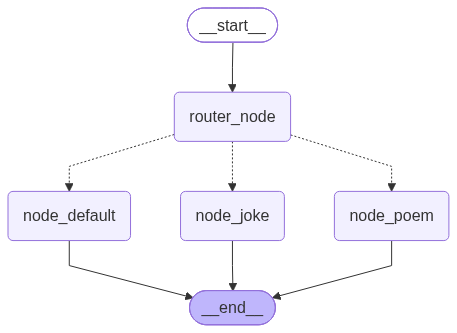

2026-08-02 19:02:34.486 | INFO     | __main__:router_node:44 - 路由节点已经执行
2026-08-02 19:02:36.032 | INFO     | __main__:router_node:49 - 路由结果为:{'topic': '荷花', 'mode': 'poem'}
2026-08-02 19:02:36.032 | INFO     | __main__:router:55 - 路由函数已经执行
2026-08-02 19:02:36.033 | INFO     | __main__:router:57 - 路由至 node_poem节点
2026-08-02 19:02:36.034 | INFO     | __main__:node_poem:68 - node_poem已经执行


{'username': '小王', 'user_input': '写一首关于荷花的诗', 'output': AIMessage(content='《荷花》\n翠盖摇风香满衣，凌波素影浴朝晖。\n蜻蜓解语藏红蕊，不染淤泥化玉扉。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 22, 'total_tokens': 56, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 22}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': 'df63b039-2100-4a49-81d0-430795239388', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fc223-d506-75e3-b8fc-224e7f2e6c1a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 22, 'output_tokens': 34, 'total_tokens': 56, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}})}


In [1]:

from typing import TypedDict, Annotated, Literal

from IPython import display
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from loguru import logger

load_dotenv()

# 获取大模型
model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)


# 1、声明状态
# 1.1 全局状态
class OverAllState(TypedDict):
    username: str
    user_input: str
    output: str


# 1.2 私有状态
class StructuredOutputState(TypedDict):
    topic: Annotated[str, "主题"]
    mode: Annotated[Literal["poem", "joke"], "模式"]


model_with_structure = model.with_structured_output(schema=StructuredOutputState)


# 2、声明节点
def router_node(state: OverAllState) -> StructuredOutputState:
    logger.info("路由节点已经执行")
    user_input = state["user_input"]
    res = model_with_structure.invoke(
        [HumanMessage(user_input)]
    )
    logger.info("路由结果为:{}", res)

    return res


def router(state: StructuredOutputState) -> Literal["node_poem", "node_joke", "node_default"]:
    logger.info("路由函数已经执行")
    if state["mode"] == "poem":
        logger.info("路由至 node_poem节点")
        return "node_poem"
    elif state["mode"] == "joke":
        logger.info("路由至 node_joke节点")
        return "node_joke"
    logger.info("路由到兜底节点")
    return "node_default"


# 2.1 写诗节点
def node_poem(state: StructuredOutputState) -> OverAllState:
    logger.info(f"node_poem已经执行")
    topic = state["topic"]
    poem = model.invoke(
        [HumanMessage(f"写一首关于{topic}主题的七言绝句，不要赏析，只写诗句部分").content]
    )
    return {
        "output": poem
    }


# 2.2 写笑话点
def node_joke(state: StructuredOutputState) -> OverAllState:
    logger.info(f"node_joke已经执行")
    topic = state["topic"]
    joke = model.invoke(
        [HumanMessage(f"写一个关于{topic}主题的笑话，字数限制在100以内").content]
    )
    return {
        "output": joke
    }


# 2.3 兜底节点
def node_default(state: StructuredOutputState) -> OverAllState:
    logger.info(f"node_default已经执行")
    return {
        "output": "无法处理的任务类型"
    }


# 3、构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("router_node", router_node)
builder.add_node("node_poem", node_poem)
builder.add_node("node_joke", node_joke)
builder.add_node("node_default", node_default)

builder.add_edge(START, "router_node")
builder.add_conditional_edges("router_node", router, path_map=[
    "node_poem", "node_joke", "node_default"
])
builder.add_edge("node_poem", END)
builder.add_edge("node_joke", END)
builder.add_edge("node_default", END)

# 4、添加内存的检查点
checkpointer = InMemorySaver()
config = {"configurable": {"thread_id": "123"}}
graph = builder.compile(checkpointer=checkpointer)
display.display(graph)

res = graph.invoke({"username": "小王", "user_input": "写一首关于荷花的诗"}, config=config)
print(res)

In [2]:
# 查看历史检查点
history_checkpoints = list(graph.get_state_history(config=config))
print(history_checkpoints)

[StateSnapshot(values={'username': '小王', 'user_input': '写一首关于荷花的诗', 'output': AIMessage(content='《荷花》\n翠盖摇风香满衣，凌波素影浴朝晖。\n蜻蜓解语藏红蕊，不染淤泥化玉扉。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 22, 'total_tokens': 56, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 22}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': 'df63b039-2100-4a49-81d0-430795239388', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fc223-d506-75e3-b8fc-224e7f2e6c1a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 22, 'output_tokens': 34, 'total_tokens': 56, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}}), 'topic': '荷花', 'mode': 'poem'}, next=(), config={'configurable': {'thread_id': '123', 'chec

In [3]:
# 获取某一个节点的位置
before_router_checkpoint = next(h for h in history_checkpoints if h.next == ('router_node',))
print(before_router_checkpoint)

StateSnapshot(values={'username': '小王', 'user_input': '写一首关于荷花的诗'}, next=('router_node',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f18e61a-a459-6201-8000-60743c82139c'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-02T11:02:34.485350+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f18e61a-a452-6d9f-bfff-3f422f51823c'}}, tasks=(PregelTask(id='0b1475f2-c9fa-f1c9-4cf3-4d617f112e8b', name='router_node', path=('__pregel_pull', 'router_node'), error=None, interrupts=(), state=None, result={'topic': '荷花', 'mode': 'poem'}),), interrupts=())


In [4]:
# 改变输入
change_input = graph.update_state(
    config=before_router_checkpoint.config,
    values={"user_input": "帮我写一个荷花的笑话"},
    as_node=START
)
print(change_input)
graph.get_state(change_input)

{'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f18e629-53c4-6a10-8001-663afc5939da'}}


StateSnapshot(values={'username': '小王', 'user_input': '帮我写一个荷花的笑话'}, next=('router_node',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f18e629-53c4-6a10-8001-663afc5939da'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-08-02T11:09:08.689136+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f18e61a-a459-6201-8000-60743c82139c'}}, tasks=(PregelTask(id='d80335a1-046d-c73f-8e16-c6b0846a5f74', name='router_node', path=('__pregel_pull', 'router_node'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [5]:
# 执行
res = graph.invoke(None, config=change_input)
print(res)

2026-08-02 19:10:05.675 | INFO     | __main__:router_node:44 - 路由节点已经执行
2026-08-02 19:10:06.824 | INFO     | __main__:router_node:49 - 路由结果为:{'topic': '荷花', 'mode': 'joke'}
2026-08-02 19:10:06.825 | INFO     | __main__:router:55 - 路由函数已经执行
2026-08-02 19:10:06.825 | INFO     | __main__:router:60 - 路由至 node_joke节点
2026-08-02 19:10:06.827 | INFO     | __main__:node_joke:80 - node_joke已经执行


{'username': '小王', 'user_input': '帮我写一个荷花的笑话', 'output': AIMessage(content='荷花仙子下凡赏景，见一游客对着满池荷花长叹：“唉，出淤泥而不染，可我这身淤泥咋就洗不白呢？”  \n仙子飘然落地，轻语：“阁下莫慌，莲藕在泥里越黑越甜，您这肤色，一看就是‘莲藕精’转世——天生招人爱！”  \n游客愣住，低头看自己黝黑胳膊，憨笑：“那我能开花不？”  \n仙子含笑：“您往那一站，就是‘黑天鹅’牌荷花，自带防晒特效！”', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 118, 'prompt_tokens': 17, 'total_tokens': 135, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 17}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': '91f2aa90-1eb5-458b-ad34-91ecf8594240', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fc22a-b5ec-7dd1-afca-bb7f2e12f156-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 118, 'total_tokens': 135, 'input_token_details': {'cache_read': 0}, 'output_tok

In [6]:
# 查看历史检查点
history_checkpoints = list(graph.get_state_history(config=config))
print(history_checkpoints)

[StateSnapshot(values={'username': '小王', 'user_input': '帮我写一个荷花的笑话', 'output': AIMessage(content='荷花仙子下凡赏景，见一游客对着满池荷花长叹：“唉，出淤泥而不染，可我这身淤泥咋就洗不白呢？”  \n仙子飘然落地，轻语：“阁下莫慌，莲藕在泥里越黑越甜，您这肤色，一看就是‘莲藕精’转世——天生招人爱！”  \n游客愣住，低头看自己黝黑胳膊，憨笑：“那我能开花不？”  \n仙子含笑：“您往那一站，就是‘黑天鹅’牌荷花，自带防晒特效！”', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 118, 'prompt_tokens': 17, 'total_tokens': 135, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 17}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': '91f2aa90-1eb5-458b-ad34-91ecf8594240', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fc22a-b5ec-7dd1-afca-bb7f2e12f156-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 118, 'total_tokens': 135, 'input_token_details': {'cache_

In [10]:
# update_state调用的时候，基于as_node实现，先执行路由逻辑在完成values赋值 =>没法正确实现路由的
skip_router_config = graph.update_state(
    config=before_router_checkpoint.config,
    # 下面两个执行的效果不一样？请问是为什么
    # values={"topic": "狸花猫", "mode": "joke"},
    values={"topic": "狸花猫", "mode": "笑话"},
    as_node="router_node"
)
print(skip_router_config)

graph.get_state(skip_router_config)

2026-08-02 19:15:41.987 | INFO     | __main__:router:55 - 路由函数已经执行
2026-08-02 19:15:41.988 | INFO     | __main__:router:60 - 路由至 node_joke节点


{'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f18e637-fa93-629e-8001-979f92dfaaa1'}}


StateSnapshot(values={'username': '小王', 'user_input': '写一首关于荷花的诗', 'topic': '狸花猫', 'mode': 'joke'}, next=('node_joke',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f18e637-fa93-629e-8001-979f92dfaaa1'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-08-02T11:15:41.989731+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f18e61a-a459-6201-8000-60743c82139c'}}, tasks=(PregelTask(id='4e69048a-f5c3-4879-6cbd-9c88b2aa5765', name='node_joke', path=('__pregel_pull', 'node_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [11]:
graph.invoke(None, config=skip_router_config)

2026-08-02 19:15:44.845 | INFO     | __main__:node_joke:80 - node_joke已经执行


{'username': '小王',
 'user_input': '写一首关于荷花的诗',
 'output': AIMessage(content='问：为什么狸花猫从不买手机？  \n答：因为它自带“虎斑纹”信号满格，每天在小区“蹭网”——靠蹭树、蹭墙、蹭快递箱，就能收到全楼八卦。  \n主人都怕它刷视频，毕竟它一刷就刷出“流浪猫减肥教程”，还评论：“这招我早用过，假动作太明显。”', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 83, 'prompt_tokens': 19, 'total_tokens': 102, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 19}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': '0dc45036-51c6-49f0-b2b6-c8ffc8731e83', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fc22f-de4e-7a92-b6fe-98c73cbba347-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 19, 'output_tokens': 83, 'total_tokens': 102, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}})}